# Laboratorio 7
Aprendizaje por Refuerzo

- Joaquín Puente
- Daniel Dubón
- Diego Valenzuela
- Nelson García Bravatti


Una empresa de ciberseguridad opera un sistema de detección de intrusiones en redes corporativas. El
sistema monitorea el tráfico de red en tiempo real y debe decidir qué acciones tomar ante comportamientos
sospechosos: ignorar, alertar, bloquear temporalmente, o aislar el segmento afectado. El estado del sistema
en cada instante es un vector de alta dimensión que incluye métricas de tráfico, patrones de comportamiento
de usuarios, y logs de eventos recientes. La empresa quiere explorar si Deep RL puede mejorar la toma de
decisiones frente a los sistemas basados en reglas que usan actualmente.


# Task 1 (Entrega Parcial)
## Task 1.1

El equipo de ingeniería propone usar DQN estándar para este sistema. Antes de implementar cualquier cosa,
usted debe hacer un análisis crítico de esa propuesta.

a. El estado del sistema es un vector de 256 dimensiones con valores continuos. Argumenten si DQN
es arquitecturalmente apropiado para este tipo de estado. ¿Qué tipo de red usarían como
aproximador de 𝑄(𝑠, 𝑎;𝒘) y por qué, considerando que el estado no es una imagen sino un vector
numérico?

b. El espacio de acciones tiene 4 opciones discretas. Argumenten si DQN o alguna de sus variantes es
apropiado para este espacio de acciones, o si sería necesario un algoritmo diferente.

c. En el dominio de detección de intrusiones, los eventos críticos (intrusiones reles) son
extremadamente raros: ocurren en menos del 0.1% de los pasos de tiempo. Argumenten
formalmente qué consecuencia tiene esa rareza sobre el buffer de Experience Replay y sobre la
distribución de muestreo uniforme. ¿Qué variante de DQN resolvería este problema específico y
cómo?

d. El sistema actual basado en reglas tiene una tasa de falsos positivos del 8%. Si diseñaran la función
de recompensa de DQN para minimizar falsos positivos únicamente, ¿qué comportamiento
indeseable podría aprender el agente? Diseñen una función de recompensa con al menos tres
componentes que capture el objetivo real del sistema, justificando la magnitud relativa de cada uno.



### 1.1.a 

**DQN sí es arquitecturalmente apropiado para un estado de 256 variables continuas.** La restricción de DQN está en el espacio de acciones, que debe ser discreto y manejable, no en que los estados sean discretos. Una tabla no permitiría representar todos los vectores posibles de $\mathbb{R}^{256}$; una red neuronal permite aproximar valores y generalizar entre estados similares.

Usaríamos un **perceptrón multicapa (MLP)** con capas completamente conectadas. Una arquitectura inicial, sujeta a validación, sería:

$$
\mathbf{s}\in\mathbb{R}^{256}
\longrightarrow \operatorname{Dense}(256)+\operatorname{ReLU}
\longrightarrow \operatorname{Dense}(128)+\operatorname{ReLU}
\longrightarrow \operatorname{Dense}(4).
$$

La salida sería el vector

$$
Q(\mathbf{s},\cdot;\mathbf{w})=
\begin{bmatrix}
Q(\mathbf{s},\text{ignorar};\mathbf{w}) &
Q(\mathbf{s},\text{alertar};\mathbf{w}) &
Q(\mathbf{s},\text{bloquear};\mathbf{w}) &
Q(\mathbf{s},\text{aislar};\mathbf{w})
\end{bmatrix}.
$$

La última capa tendría activación **lineal**, porque los valores $Q$ son retornos esperados, posiblemente negativos, y no probabilidades. No usaríamos *softmax*. Estandarizaríamos las entradas con estadísticas del conjunto de entrenamiento para que, por ejemplo, el volumen de tráfico no domine por su escala a otras métricas.

Una MLP puede aprender interacciones no lineales entre las variables. Una CNN no sería la primera elección porque el orden de las 256 métricas no implica vecindad espacial ni patrones trasladables como los de una imagen. Tampoco convertiríamos arbitrariamente el vector en una imagen.

La viabilidad depende además de la representación: el vector debe resumir suficiente historia para aproximar un estado de Markov. Si dos situaciones con el mismo vector requieren decisiones diferentes por eventos anteriores, habría observabilidad parcial; ampliaríamos las ventanas temporales o consideraríamos una red recurrente. Tener 256 entradas, por sí solo, no garantiza que DQN aprenda una buena política.


### 1.1.b 

El conjunto $\mathcal{A}=\{\text{ignorar},\text{alertar},\text{bloquear},\text{aislar}\}$ **encaja directamente con DQN y sus variantes**. Con cuatro salidas, la red calcula todos los valores en una sola evaluación y la acción codiciosa se obtiene mediante

$$
a_t=\arg\max_{a\in\mathcal A}Q(s_t,a;\mathbf w).
$$

Comparar cuatro números es barato, tanto para actuar como para calcular el máximo del target. No hace falta otro algoritmo por la dimensionalidad continua del estado.

Usaríamos DQN como referencia experimental y consideraríamos **Double DQN con Prioritized Experience Replay (PER)**: Double DQN reduce el sesgo de sobreestimación y PER mejora el aprovechamiento de transiciones con alto error TD. Son modificaciones compatibles que atienden problemas distintos. Dueling también sería compatible, aunque las cuatro acciones no lo hacen obligatorio.

Esta conclusión supone que cada acción está bien definida, por ejemplo, que la duración del bloqueo y el segmento que se aísla están determinados por el entorno. Si el agente también tuviera que elegir una duración continua, cambiaría el espacio de acciones y habría que reconsiderar la formulación. En el problema planteado no se necesita ese cambio.

### 1.1.c 

Sea $p<0.001$ la probabilidad de que una transición sea crítica, $N$ el número de transiciones de un buffer lleno y $K$ la cantidad de transiciones críticas almacenadas. Si el buffer representa un proceso con esa frecuencia estable,

$$
\mathbb E[K]=Np<0.001N.
$$

Por ejemplo, con $N=10\,000$ habría **menos de 10 transiciones críticas en promedio**. Bajo el supuesto adicional de eventos independientes, $K\sim\operatorname{Binomial}(N,p)$ y

$$
P(K=0)=(1-p)^N.
$$

Con $N=1\,000$ y $p=0.001$ como referencia límite, esta probabilidad es aproximadamente $36.8\%$; con una frecuencia menor aumenta. Las intrusiones reales pueden agruparse temporalmente, por lo que el modelo binomial es una simplificación, no una propiedad garantizada del tráfico. Además, el reemplazo FIFO puede eliminar una experiencia crítica antes de que se aproveche suficientemente.

**Muestreo uniforme.** Cada transición almacenada tiene probabilidad $1/N$, por lo que la probabilidad de obtener una crítica en una extracción es $K/N$, no $1/2$. Para un minibatch de tamaño $B$, la cantidad de ejemplos críticos $X$, condicionada al buffer, satisface

$$
\mathbb E[X\mid K]=B\frac{K}{N}.
$$

Con reemplazo, $P(X=0\mid K)=(1-K/N)^B$; sin reemplazo,

$$
P(X=0\mid K)=\frac{\binom{N-K}{B}}{\binom NB}.
$$

Cuando $K/N\approx p$, usando $B=64$ y $p=0.001$ como referencia, se obtiene $\mathbb E[X]\approx0.064$ y $P(X=0)\approx0.999^{64}\approx93.8\%$. Por tanto, casi todos los minibatches carecerían de ejemplos críticos. El replay uniforme reduce la correlación temporal, pero **no equilibra las clases**: la mayoría de actualizaciones usa tráfico normal. Esto dificulta aprender las consecuencias de decisiones durante ataques, aunque el tamaño del gradiente también depende de las recompensas y del error TD.

**Variante propuesta: Prioritized Experience Replay.** Para cada transición $i$, definimos

$$
\delta_i=y_i-Q(s_i,a_i;\mathbf w),\qquad
p_i=|\delta_i|+\epsilon,\qquad
P(i)=\frac{p_i^\alpha}{\sum_{j=1}^{N}p_j^\alpha},
$$

donde $\epsilon>0$ evita probabilidades nulas y $\alpha\in[0,1]$ regula la priorización; $\alpha=0$ recupera el muestreo uniforme. Una intrusión mal predicha, especialmente con consecuencias de gran magnitud, puede generar un error TD alto y reutilizarse con mayor frecuencia. Las prioridades se actualizan al recalcular los errores.

El muestreo deja de ser uniforme. Para corregir su sesgo respecto al objetivo de replay uniforme, pueden ponderarse las pérdidas con pesos de importancia

$$
\omega_i=(N P(i))^{-\beta},\qquad 0\leq\beta\leq1,
$$

habitualmente normalizados por un máximo común. Con $\beta=1$, el factor sin normalizar satisface $\mathbb E_{i\sim P}[\omega_i\ell_i]=\frac1N\sum_i\ell_i$ para una pérdida por transición $\ell_i$; valores menores aplican una corrección parcial. Se prioriza dónde aprender sin confundir esa frecuencia de entrenamiento con la prevalencia real de ataques.

**Alcance:** PER atiende la ineficiencia del muestreo, pero prioriza sorpresa, no rareza ni importancia de seguridad directamente. No garantiza que todo ataque tenga alto error TD, no genera ataques ausentes y no impide su expulsión FIFO. Si faltara cobertura, lo complementaríamos con retención de incidentes o muestreo estratificado, ajustando los pesos a la distribución efectivamente utilizada. Double DQN por sí solo no soluciona este problema de muestreo.


### 1.1.d 

Si solamente penalizáramos los falsos positivos, por ejemplo $r_{t+1}=-\mathbf1\{\text{falso positivo}\}$, el agente podría aprender a **ignorar todo el tráfico**. Así no emitiría falsas alarmas ni bloquearía usuarios legítimos, pero dejaría pasar todas las intrusiones. Reducir el 8% de falsos positivos a 0% no demostraría una mejora de seguridad: esa tasa se calcula sobre tráfico benigno y no mide los falsos negativos.

Proponemos recompensar la contención efectiva y penalizar tanto el daño de ataques como el de intervenciones innecesarias. Definimos, para cada transición:

- $z_t\in\{0,1\}$: indica si hay una intrusión real, verificada por el entorno de entrenamiento o por análisis posterior.
- $c_t\in\{0,1\}$: indica que en esa transición se contiene exitosamente la intrusión; se recompensa una sola vez por incidente.
- $h_t\in[0,1]$: daño de seguridad durante el intervalo, medido en una escala fija; $h_t=1$ representa una unidad de daño grave por una intrusión no contenida.
- $f(a_t)$: costo adicional de una intervención sobre tráfico benigno.
- $o(a_t)$: costo operativo de ejecutar una acción, haya o no intrusión.

Una recompensa ilustrativa de **cuatro componentes** sería

$$
\boxed{r_{t+1}=20z_tc_t-1000z_th_t-(1-z_t)f(a_t)-o(a_t).}
$$

| Acción | $f(a)$: intervención injustificada | $o(a)$: costo operativo |
|---|---:|---:|
| Ignorar | 0 | 0 |
| Alertar | 1 | 0.1 |
| Bloquear temporalmente | 10 | 0.5 |
| Aislar el segmento | 50 | 2 |

La magnitud relativa responde a estos objetivos:

1. **Daño por intrusión ($-1000z_th_t$):** es el costo dominante de un evento grave, porque un compromiso puede causar pérdidas mucho mayores que una alerta innecesaria. Penaliza las consecuencias de omitir o retrasar una respuesta efectiva.
2. **Contención verificada ($+20z_tc_t$):** reconoce resolver un ataque, sin premiar simplemente emitir alertas o repetir bloqueos. Es menor que la penalización por daño grave para que detectar tarde no compense arbitrariamente el daño producido.
3. **Intervención injustificada ($-(1-z_t)f(a_t)$):** aislar un segmento legítimo cuesta más que bloquear una conexión, y bloquear cuesta más que alertar. Este término desalienta resolver la seguridad interrumpiendo indiscriminadamente el servicio.
4. **Costo operativo ($-o(a_t)$):** representa recursos de análisis y ejecución. Entre dos acciones igualmente efectivas, favorece la menos costosa; es menor que el costo de dañar tráfico legítimo y mucho menor que el de una intrusión grave.

Por ejemplo, ignorar tráfico benigno produce $0$; alertar sobre él, $-1.1$; bloquearlo, $-10.5$; aislarlo, $-52$. Contener por primera vez un ataque mediante bloqueo y sin daño en ese intervalo produce $19.5$, mientras que ignorarlo y permitir $h_t=1$ produce $-1000$. Si alertar activa una respuesta humana que contiene el ataque después, ese beneficio aparece en las transiciones posteriores y contribuye al retorno descontado.

Los valores son una **propuesta de escala, no costos estimados de la empresa**. Deben calibrarse con el daño real, la duración del paso temporal y la prevalencia de ataques. En una comparación simplificada de un paso, si $q=P(z_t=1\mid s_t)$, ignorar un ataque siempre genera $h_t=1$ y bloquear siempre lo contiene sin daño, entonces

$$
\mathbb E[r\mid\text{ignorar}]=-1000q,\qquad
\mathbb E[r\mid\text{bloquear}]=19.5q-10.5(1-q)=30q-10.5.
$$

Bloquear sería preferible si $q>10.5/1030\approx1.02\%$. Esto muestra cómo los pesos fijan un intercambio entre seguridad y disponibilidad: con ataques muy raros hace falta distinguir estados de riesgo elevado; los coeficientes no garantizan por sí solos una política útil. En el MDP completo también cuentan los efectos futuros, mediante $G_t=\sum_{k=0}^{\infty}\gamma^k r_{t+k+1}$.

Evaluaríamos la política frente al sistema de reglas usando conjuntamente falsos positivos, ataques omitidos, daño y disponibilidad. La verdad de referencia que determina $z_t$, $c_t$ y $h_t$ debe provenir de resultados verificados, no de las propias predicciones del agente, para evitar recompensarlo por declarar que acertó.


## Task 1.2

El equipo propone usar Double DQN en lugar de DQN estándar.

a. Expliquen formalmente el problema de sobreestimación que Double DQN resuelve. En el contexto
específico de detección de intrusiones, ¿qué consecencia operacional tendría que el agente
sobreestime sistemáticamente el valor de la acción "bloquear"? ¿Y de la acción "ignorar"?

b. Escriban la expresión del target de DQN estándar y la del target de Double DQN, identificando con
precisión qué parámetros hacen qué en cada caso. ¿Cuál es el único cambio de implementación
entre ambos?

c. Argumenten si en este dominio específico la sobreestimación es un problema más grave en ciertos
tipos de estados que en otros. Consideren estados con alta ambigüedad (tráfico borderline) versus
estados claramente maliciosos.

### 1.2.a 

En DQN, el máximo del target selecciona y evalúa una acción utilizando las mismas estimaciones de la red objetivo. Para formalizar el sesgo, fijemos un siguiente estado $s'$ y supongamos

$$
Q(s',a;\mathbf w^-)=q_*(s',a)+\varepsilon_a,
\qquad \mathbb E[\varepsilon_a]=0.
$$

Aunque cada estimación sea individualmente insesgada, la convexidad del máximo implica

$$
\mathbb E\!\left[\max_a\big(q_*(s',a)+\varepsilon_a\big)\right]
\geq
\max_a\mathbb E\!\left[q_*(s',a)+\varepsilon_a\right]
=\max_a q_*(s',a).
$$

El máximo tiende a escoger acciones cuyo error fue favorable. La desigualdad puede ser estricta cuando el ruido cambia la acción ganadora; no significa que cada estimación esté siempre sobreestimada. Por ejemplo, con dos acciones de valor real cero y errores independientes $+1$ o $-1$ equiprobables, el máximo vale $+1$ con probabilidad $3/4$ y $-1$ con probabilidad $1/4$: su esperanza es $0.5$, aunque el mejor valor real es $0$. Ese optimismo entra en el target multiplicado por $\gamma$ y puede propagarse mediante bootstrapping.

**Double DQN reduce este efecto separando selección y evaluación:** la red principal elige la acción y la red objetivo estima su valor. Ya no se toma directamente el mayor error de la red que evalúa. No elimina todo sesgo: ambas redes están relacionadas por las copias periódicas de parámetros, por lo que sus errores pueden seguir correlacionados; incluso puede haber subestimación.

En detección de intrusiones, si la sobreestimación altera la preferencia entre acciones:

- **Sobreestimar «bloquear»** puede llevar a bloquear tráfico legítimo innecesariamente, aumentar falsos positivos e interrumpir servicios. El agente interpreta que bloquear tiene más beneficio o menos costo del real.
- **Sobreestimar «ignorar»** puede llevar a omitir respuestas ante ataques, aumentar falsos negativos, retrasar la contención y permitir propagación o exfiltración. Que el valor real sea negativo no impide la sobreestimación: pasar de $-100$ a $-5$ ya hace parecer mucho mejor esa acción.

Un desplazamiento idéntico de todos los valores no cambia necesariamente la decisión inmediata; el riesgo operacional surge especialmente cuando el error cambia cuál acción parece mejor.


### 1.2.b 

Sea $(s,a,r,s',d)$ una transición, con $r=r_{t+1}$ y $d=1$ si $s'$ es un estado terminal real; en otro caso $d=0$. Denotamos por $\mathbf w$ los parámetros de la **red principal**, actualizados por gradiente, y por $\mathbf w^-$ los de la **red objetivo**, mantenidos fijos entre copias periódicas $\mathbf w^-\leftarrow\mathbf w$. Ambas redes tienen la misma arquitectura.

**DQN estándar:**

$$
\boxed{y^{\mathrm{DQN}}=r+\gamma(1-d)\max_{a'\in\mathcal A}Q(s',a';\mathbf w^-).}
$$

La red objetivo $\mathbf w^-$ realiza ambas funciones: el máximo identifica la acción y devuelve su valor usando esa misma red.

**Double DQN:**

$$
a_{\mathrm{sel}}=\arg\max_{a'\in\mathcal A}Q(s',a';\mathbf w),
$$
$$
\boxed{y^{\mathrm{DDQN}}=r+\gamma(1-d)Q(s',a_{\mathrm{sel}};\mathbf w^-).}
$$

Aquí $\mathbf w$ **selecciona** la acción y $\mathbf w^-$ la **evalúa**. El factor $(1-d)$ evita bootstrap al terminar un episodio: en ambos métodos, si $d=1$, el target es $r$. Un corte artificial por límite de tiempo no necesariamente representa un estado terminal del MDP.

**El único cambio algorítmico entre las versiones base está en el cálculo del valor del siguiente estado dentro del target:** sustituir el máximo de la red objetivo por el valor que esta asigna a la acción seleccionada por la red principal. En pseudocódigo para un minibatch:

```python
# Todo este bloque se calcula sin construir gradientes.
q_target = target_network(next_states)       # Forma: [B, 4]

# DQN:
next_value_dqn = max_over_actions(q_target)  # Forma: [B]

# Double DQN, en sustitución de la línea anterior:
q_online = online_network(next_states)      # Forma: [B, 4]
selected = argmax_over_actions(q_online)    # Forma: [B]
next_value_ddqn = q_target[rows, selected]   # rows = 0, ..., B-1

target = rewards + gamma * (1 - terminal) * next_value_ddqn
```

Se conservan la arquitectura, el buffer, la política de exploración y el mecanismo de actualización de la red objetivo. DQN ya tenía dos redes; Double DQN no requiere agregar una tercera. Sí puede requerir una evaluación adicional de la red principal en $s'$, según qué cálculos se reutilicen.

En ambos casos se minimiza, por ejemplo,

$$
L(\mathbf w)=\frac1B\sum_{i=1}^{B}
\left(\operatorname{stopgrad}(y_i)-Q(s_i,a_i;\mathbf w)\right)^2.
$$

El gradiente actualiza $\mathbf w$ a través de $Q(s_i,a_i;\mathbf w)$, **no a través del target**, ni siquiera cuando $\mathbf w$ interviene en la selección de Double DQN. Si además se usa PER, se ponderan los términos con $\omega_i$; eso es una modificación independiente.


### 1.2.c 

La sobreestimación **no tiene el mismo efecto en todos los estados**. Conviene distinguir la probabilidad de elegir una acción equivocada de la gravedad de sus consecuencias.

En tráfico ambiguo, como un aumento de conexiones que podría ser una copia de respaldo o un ataque, suele haber incertidumbre y valores relativamente cercanos para ignorar, alertar y bloquear. Sea $a^*$ la mejor acción real y definamos la separación respecto a otra acción $b$:

$$
\Delta_b(s)=q_*(s,a^*)-q_*(s,b)>0.
$$

Si $\hat Q(s,a)=q_*(s,a)+\varepsilon_a$, la acción inferior $b$ supera a $a^*$ cuando

$$
\varepsilon_b-\varepsilon_{a^*}>\Delta_b(s).
$$

Para una misma distribución de errores, una separación pequeña hace más fácil invertir el orden. En estados ambiguos, el máximo puede seleccionar con frecuencia una estimación demasiado optimista; esto puede causar bloqueos innecesarios o ignorar ataques incipientes. Double DQN es especialmente útil para reducir el optimismo que se introduce en los targets en estas situaciones, aunque no resuelve la ambigüedad de las observaciones.

En estados claramente maliciosos, **si están bien representados en los datos y la recompensa está bien diseñada**, las acciones efectivas de contención deberían tener valores claramente superiores a ignorar. Si la separación supera ampliamente el error de estimación, un error moderado no cambiaría la acción elegida. En ese sentido, la decisión sería más robusta.

Sin embargo, «claramente malicioso» para un analista no implica «bien aprendido» por la red. Dado que las intrusiones son raras, esos estados pueden tener poco soporte en el replay y errores grandes. Además, confundir bloquear con ignorar durante un ataque grave puede ser mucho más costoso que una decisión incorrecta en tráfico ambiguo. Incluso ante un ataque evidente, bloquear y aislar podrían tener valores cercanos entre sí.

Por tanto, esperaríamos mayor sensibilidad al ruido en estados ambiguos con acciones de valor similar, pero potencialmente mayor daño por error en ataques graves poco representados. La evaluación debe separar ambos tipos de estados. **Double DQN aborda el sesgo del máximo y PER ayuda a reutilizar experiencias mal aprendidas; ninguno garantiza seguridad ni buena cobertura por sí solo.**


## Task 2 (Entrega Final)

### Task 2.1

Implementación de DQN y Double DQN desde cero (PyTorch) sobre `LunarLander-v3` (la versión `v2`
usada en el enunciado está deprecada en la versión actual de Gymnasium; `v3` conserva la misma
dinámica, espacio de estados $\mathbb R^8$ y espacio de acciones discreto $\{0,1,2,3\}$, por lo que
funciona como el mismo proxy del sistema de detección de intrusiones). El código está comentado en
inglés (convención del proyecto) señalando la relación de cada bloque con las fórmulas de las
diapositivas [P] y con los incisos de la Task 1.

In [1]:
import random
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# Hyperparameters fixed by the assignment statement.
HIDDEN_SIZE = 128          # two hidden layers of 128 units (Q(s,a;w) approximator)
REPLAY_CAPACITY = 50_000   # Experience Replay buffer capacity
BATCH_SIZE = 64            # minibatch size sampled from the replay buffer
TARGET_UPDATE_EVERY = 500  # steps between target-network syncs (w- <- w)
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY_STEPS = 10_000  # steps over which epsilon decays linearly
GAMMA = 0.99
LEARNING_RATE = 5e-4
N_EVAL_STATES = 100

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


In [2]:
class QNetwork(nn.Module):
    """MLP approximator for Q(s, a; w): state vector in, one Q-value per action out.

    This is the network referenced in Task 1.1a: since the state is a numeric vector
    (not an image), a fully connected network is architecturally appropriate instead
    of a convolutional one.
    """

    def __init__(self, state_dim: int, n_actions: int, hidden_size: int = HIDDEN_SIZE):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(state_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        return self.body(state)


In [3]:
class ReplayBuffer:
    """Uniform-sampling Experience Replay buffer (slide [P], block 4).

    Transitions (s, a, r, s', done) are stored in a fixed-capacity ring buffer and
    sampled uniformly at random to break the temporal correlation between
    consecutive steps, as required to train Q(s, a; w) with i.i.d.-like minibatches.
    """

    def __init__(self, capacity: int = REPLAY_CAPACITY):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int = BATCH_SIZE):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.as_tensor(np.array(states), dtype=torch.float32),
            torch.as_tensor(actions, dtype=torch.int64),
            torch.as_tensor(rewards, dtype=torch.float32),
            torch.as_tensor(np.array(next_states), dtype=torch.float32),
            torch.as_tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)


In [4]:
class DQNAgent:
    """DQN / Double DQN agent, selectable with a single flag.

    Per Task 1.2b, DQN and Double DQN share the exact same update rule and differ
    in a single line: which network selects the greedy next action used in the
    target. Both variants are implemented here to make that single difference
    explicit rather than duplicating the whole training loop.

        DQN target:         y = r + gamma * (1 - done) * max_a' Q(s', a'; w-)
        Double DQN target:  y = r + gamma * (1 - done) * Q(s', argmax_a' Q(s', a'; w); w-)

    w  = online network parameters (updated every step by gradient descent)
    w- = target network parameters (frozen, synced from w every TARGET_UPDATE_EVERY steps)
    """

    def __init__(self, state_dim: int, n_actions: int, double_dqn: bool):
        self.n_actions = n_actions
        self.double_dqn = double_dqn

        self.online_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.online_net.parameters(), lr=LEARNING_RATE)
        self.replay_buffer = ReplayBuffer()

        self.total_steps = 0

    def epsilon(self) -> float:
        # Linear decay from EPSILON_START to EPSILON_END over EPSILON_DECAY_STEPS steps.
        fraction = min(1.0, self.total_steps / EPSILON_DECAY_STEPS)
        return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)

    def select_action(self, state: np.ndarray) -> int:
        # Epsilon-greedy exploration: a_t = argmax_a Q(s, a; w) with probability 1 - eps.
        if random.random() < self.epsilon():
            return random.randrange(self.n_actions)
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q_values = self.online_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def maybe_sync_target(self):
        if self.total_steps % TARGET_UPDATE_EVERY == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def train_step(self):
        """One gradient step on a sampled minibatch. Returns the mean target y (for logging)."""
        if len(self.replay_buffer) < BATCH_SIZE:
            return None

        states, actions, rewards, next_states, dones = self.replay_buffer.sample()
        states, actions = states.to(DEVICE), actions.to(DEVICE)
        rewards, next_states, dones = rewards.to(DEVICE), next_states.to(DEVICE), dones.to(DEVICE)

        # Q(s, a; w) for the actions actually taken.
        q_values = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            if self.double_dqn:
                # Selection with w (online), evaluation with w- (target) -> decouples
                # the two roles that cause DQN's maximization bias (Task 1.2a/1.2b).
                next_actions = self.online_net(next_states).argmax(dim=1)
                next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            else:
                # Standard DQN: the same network (w-) both selects and evaluates the
                # greedy next action, which is the source of the overestimation bias.
                next_q = self.target_net(next_states).max(dim=1)[0]

            targets = rewards + GAMMA * (1.0 - dones) * next_q

        loss = F.mse_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return targets.mean().item()

    def step(self, state, action, reward, next_state, done):
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.total_steps += 1
        mean_target = self.train_step()
        self.maybe_sync_target()
        return mean_target


In [5]:
def collect_fixed_eval_states(env_name: str, n_states: int = N_EVAL_STATES, seed: int = 0):
    """Collect a fixed set of states with a random policy, used to track avg Q(s, a; w)
    over a stable state distribution during training (needed to detect overestimation,
    Task 2.1 logging requirement / Task 2.2b).
    """
    env = gym.make(env_name)
    states = []
    state, _ = env.reset(seed=seed)
    while len(states) < n_states:
        states.append(state)
        action = env.action_space.sample()
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            state, _ = env.reset()
    env.close()
    return torch.as_tensor(np.array(states), dtype=torch.float32, device=DEVICE)


def mean_eval_q(agent: DQNAgent, eval_states: torch.Tensor) -> float:
    with torch.no_grad():
        q_values = agent.online_net(eval_states)
    return q_values.max(dim=1)[0].mean().item()


In [6]:
def train_agent(env_name: str, double_dqn: bool, n_episodes: int, eval_states: torch.Tensor, seed: int = 0):
    """Runs one full training loop and logs, per episode: total reward, average Q
    over the fixed evaluation states, and the average target y used in that episode's
    updates (Task 2.1 logging requirement).
    """
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = DQNAgent(state_dim, n_actions, double_dqn=double_dqn)

    episode_rewards, avg_q_log, avg_target_log = [], [], []

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0.0
        episode_targets = []
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            mean_target = agent.step(state, action, reward, next_state, terminated)
            if mean_target is not None:
                episode_targets.append(mean_target)

            state = next_state
            episode_reward += reward

        episode_rewards.append(episode_reward)
        avg_q_log.append(mean_eval_q(agent, eval_states))
        avg_target_log.append(np.mean(episode_targets) if episode_targets else float("nan"))

        if (episode + 1) % 50 == 0:
            recent = np.mean(episode_rewards[-20:])
            print(f"[{'DoubleDQN' if double_dqn else 'DQN'}] episode {episode + 1}/{n_episodes} "
                  f"reward(20-ep avg)={recent:.1f} epsilon={agent.epsilon():.3f}")

    env.close()
    return {
        "agent": agent,
        "reward": episode_rewards,
        "avg_q": avg_q_log,
        "avg_target": avg_target_log,
    }


In [7]:
ENV_NAME = "LunarLander-v3"
N_EPISODES = 600

eval_states = collect_fixed_eval_states(ENV_NAME)

dqn_logs = train_agent(ENV_NAME, double_dqn=False, n_episodes=N_EPISODES, eval_states=eval_states, seed=0)
double_dqn_logs = train_agent(ENV_NAME, double_dqn=True, n_episodes=N_EPISODES, eval_states=eval_states, seed=0)


[DQN] episode 50/600 reward(20-ep avg)=-129.7 epsilon=0.440


[DQN] episode 100/600 reward(20-ep avg)=-33.4 epsilon=0.050


[DQN] episode 150/600 reward(20-ep avg)=-24.4 epsilon=0.050


[DQN] episode 200/600 reward(20-ep avg)=-0.7 epsilon=0.050


[DQN] episode 250/600 reward(20-ep avg)=156.1 epsilon=0.050


...

[DoubleDQN] episode 400/600 reward(20-ep avg)=212.9 epsilon=0.050


[DoubleDQN] episode 450/600 reward(20-ep avg)=141.8 epsilon=0.050


[DoubleDQN] episode 500/600 reward(20-ep avg)=195.0 epsilon=0.050


[DoubleDQN] episode 550/600 reward(20-ep avg)=236.8 epsilon=0.050


[DoubleDQN] episode 600/600 reward(20-ep avg)=270.7 epsilon=0.050


In [8]:
import csv

for name, logs in [("dqn", dqn_logs), ("double_dqn", double_dqn_logs)]:
    with open(f"{name}_logs.csv", "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["episode", "reward", "avg_q", "avg_target"])
        for i, (r, q, t) in enumerate(zip(logs["reward"], logs["avg_q"], logs["avg_target"])):
            writer.writerow([i, r, q, t])

print("DQN        last-20-episode avg reward:", np.mean(dqn_logs["reward"][-20:]))
print("Double DQN last-20-episode avg reward:", np.mean(double_dqn_logs["reward"][-20:]))


DQN        last-20-episode avg reward: 257.79831369287587
Double DQN last-20-episode avg reward: 270.70011913563354


### Task 2.2

#### a.

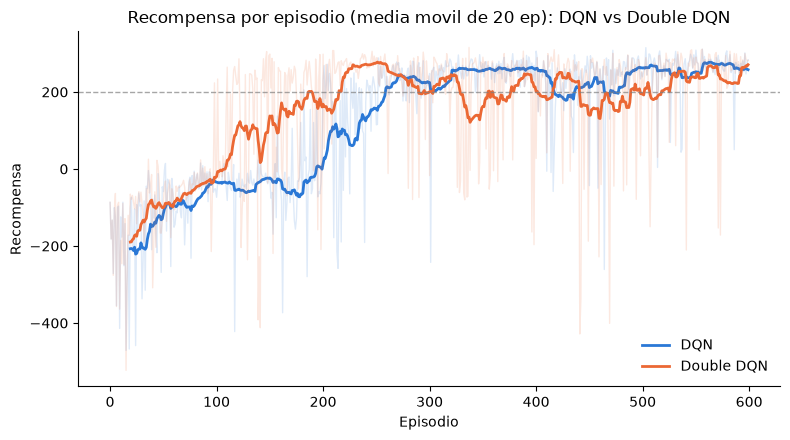

In [9]:
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"


def moving_average(x, window=20):
    return np.convolve(x, np.ones(window) / window, mode="valid")


def plot_reward_curves(runs, threshold=200):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for logs, color, label in runs:
        reward = np.array(logs["reward"])
        ma = moving_average(reward, 20)
        ax.plot(reward, color=color, alpha=0.15, linewidth=1)
        ax.plot(np.arange(19, len(reward)), ma, color=color, linewidth=2, label=label)
    ax.axhline(threshold, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Episodio")
    ax.set_ylabel("Recompensa")
    ax.legend(frameon=False, loc="lower right")
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    return fig, ax


fig, ax = plot_reward_curves([(dqn_logs, BLUE, "DQN"), (double_dqn_logs, ORANGE, "Double DQN")])
ax.set_title("Recompensa por episodio (media movil de 20 ep): DQN vs Double DQN")
plt.tight_layout()
plt.show()

Viendo la grafica, Double DQN converge mas rapido que DQN. Si tomamos como referencia el umbral de "resuelto" (200 de recompensa, con media movil de 20 episodios), Double DQN lo cruza como en el episodio 188, mientras que DQN lo cruza hasta el episodio 260, osea casi 70 episodios despues. Eso se nota bastante en la parte de en medio de la grafica, donde la curva naranja (Double DQN) ya esta arriba de 100 cuando la azul (DQN) todavia anda en negativo.

En cuanto a la recompensa final la cosa ya no es tan clara. Si promediamos los ultimos 20 episodios, Double DQN queda un poco arriba (270.7 vs 257.8 de DQN), pero si promediamos los ultimos 100 episodios pasa lo contrario, DQN queda mas alto (259.8 vs 238.4). Esto es porque Double DQN se ve mas inestable en la parte final del entrenamiento, tiene una caida notoria alrededor del episodio 450-480 (se le ve en la grafica un valle que baja hasta como 140-150), cosa que DQN no hace tan marcado. La desviacion estandar de la recompensa en los ultimos 150 episodios lo confirma: 121 para Double DQN contra 73 de DQN. O sea Double DQN aprende mas rapido pero se queda un poco menos estable ya entrado el entrenamiento, al menos en esta corrida.

Esto coincide solo a medias con lo que dice la teoria. Se esperaria que Double DQN converja mas rapido y de forma mas estable porque corrige el sesgo de sobreestimacion de DQN (evita que el bootstrap se infle con el ruido de la red), y efectivamente convergio mas rapido. Pero no fue mas estable al final, si no lo contrario. Hay que tener en cuenta que esto es una sola semilla en un entorno con bastante aleatoriedad (el viento, la posicion inicial del lander, etc), entonces una corrida sola no es evidencia fuerte de que un algoritmo sea "mejor" que el otro en cuanto a estabilidad, para afirmar eso con mas seguridad habria que correr varias semillas y comparar promedios con su intervalo de confianza. Lo que si se puede decir con mas confianza, porque se ve consistente en toda la fase de aprendizaje temprano, es que Double DQN llega a buena recompensa mas rapido.

#### b.

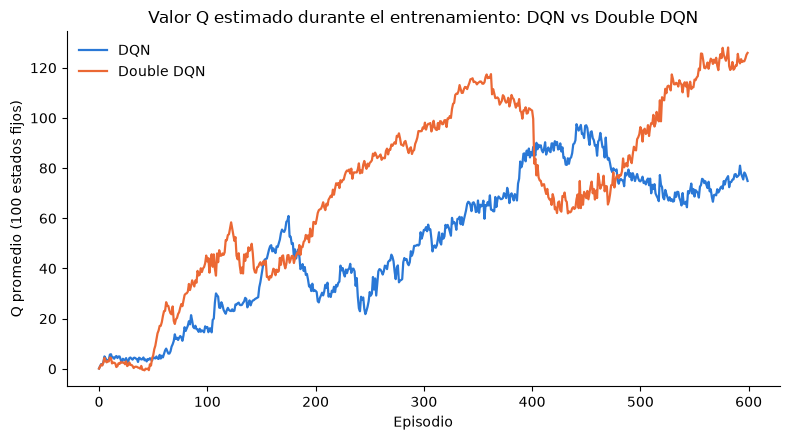

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dqn_logs["avg_q"], color=BLUE, linewidth=1.6, label="DQN")
ax.plot(double_dqn_logs["avg_q"], color=ORANGE, linewidth=1.6, label="Double DQN")
ax.set_xlabel("Episodio")
ax.set_ylabel("Q promedio (100 estados fijos)")
ax.set_title("Valor Q estimado durante el entrenamiento: DQN vs Double DQN")
ax.legend(frameon=False, loc="upper left")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

No observamos el patron esperado, de hecho nos salio al reves: en nuestra corrida el Q promedio de Double DQN termina bastante mas alto que el de DQN (114 vs 72 en promedio de los ultimos 100 episodios, con picos de hasta 128 contra 97). Osea que la curva naranja esta sistematicamente arriba de la azul en casi toda la segunda mitad del entrenamiento (en el 74% de los episodios Double DQN > DQN), justo lo opuesto a lo que dice la teoria de la Task 1.2a.

Creemos que hay varias razones por las que esto puede pasar y no necesariamente contradice la teoria de sobreestimacion:

1. **El sesgo de sobreestimacion es sobre el valor real, no entre algoritmos.** Lo que dice la teoria es que $\mathbb E[\max_a \hat Q(s,a)] \geq \max_a q_*(s,a)$, es decir que cada red sobreestima contra su *propio* valor verdadero. Eso no implica que $Q_{DQN}(s,a) > Q_{DDQN}(s,a)$ en magnitud absoluta si ademas los dos agentes terminaron aprendiendo politicas distintas. Si Double DQN encontro una politica genuinamente mejor (lo cual concuerda con el inciso a, llega a mas recompensa mas rapido), entonces su $q_*$ real bajo esa politica tambien es mas alto, y una parte de la diferencia que vemos puede ser eso: valor real mas alto, no mas sesgo.

2. **No tenemos el valor real para comparar contra el.** Para medir sobreestimacion de verdad habria que comparar $\hat Q(s,a)$ contra el retorno de Monte Carlo real desde ese estado, y nosotros no calculamos eso, solo comparamos las dos estimaciones entre si. Sin ese punto de referencia no podemos decir cual de las dos esta "mas equivocada" hacia arriba, solo que son distintas.

3. **Los 100 estados fijos se recolectaron con politica aleatoria al inicio, antes de entrenar nada.** Es un estado inicial de exploracion pura, entonces son estados que el agente ya entrenado casi no visita. Evaluar Q ahi es mas una extrapolacion fuera de la distribucion de datos que una medicion de la politica actual, y las dos redes pueden extrapolar de forma bien distinta a esos estados sin que eso refleje sobreestimacion en el sentido de la teoria.

4. Algo que nos parecio interesante: el **target promedio usado en las actualizaciones** (que si se calcula sobre estados que el agente realmente visita, via el replay buffer) termina practicamente igual entre los dos algoritmos al final del entrenamiento (80.2 para DQN vs 79.4 para Double DQN). Osea que sobre los datos "reales" de entrenamiento las dos redes bootstrapean hacia valores parecidos, pero sobre el set fijo de evaluacion divergen un monton. Esto refuerza el punto 3: la metrica de "Q promedio sobre estados fijos" esta midiendo generalizacion a estados fuera de distribucion mas que el sesgo de sobreestimacion como tal.

5. Con solo 4 acciones y recompensas acotadas, es posible tambien que el efecto de sobreestimacion (un corrimiento sistematico de unos pocos puntos por tomar el maximo sobre ruido) sea chico comparado con otras fuentes de varianza entre las dos corridas, como la inicializacion de pesos o que cada agente explora regiones distintas del espacio de estados en momentos distintos.

En resumen, si vieramos $Q_{DQN} > Q_{DDQN}$ en un experimento controlado (misma politica, mismos datos) si esperariamos que se cumpla la teoria, pero al comparar dos entrenamientos independientes que terminan en politicas distintas, la magnitud del Q aprendido depende tambien de que tan buena es la politica y de como generaliza la red a estados no visitados, no solo del sesgo del operador max.

#### c.

Implementamos PER (Schaul et al., 2016) sobre Double DQN, con $\alpha=0.6$ fijo y $\beta$ creciente de $0.4$ a $1.0$ en linea recta a lo largo de los 600 episodios. Usamos un sum-tree para que insertar y muestrear por prioridad sea $O(\log N)$ en vez de $O(N)$.

In [11]:
class SumTree:
    """Binary sum-tree: O(log N) priority updates and O(log N) proportional sampling,
    instead of the O(N) scan a plain array of priorities would need (Task 2.2c, [P] slide 10).
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity - 1)
        self.data = [None] * capacity
        self.write = 0
        self.n_entries = 0

    def _propagate(self, idx: int, change: float):
        parent = (idx - 1) // 2
        self.tree[parent] += change
        if parent != 0:
            self._propagate(parent, change)

    def _retrieve(self, idx: int, s: float) -> int:
        left = 2 * idx + 1
        right = left + 1
        if left >= len(self.tree):
            return idx
        if s <= self.tree[left]:
            return self._retrieve(left, s)
        return self._retrieve(right, s - self.tree[left])

    def total(self) -> float:
        return self.tree[0]

    def add(self, priority: float, data):
        idx = self.write + self.capacity - 1
        self.data[self.write] = data
        self.update(idx, priority)
        self.write = (self.write + 1) % self.capacity
        self.n_entries = min(self.n_entries + 1, self.capacity)

    def update(self, idx: int, priority: float):
        change = priority - self.tree[idx]
        self.tree[idx] = priority
        self._propagate(idx, change)

    def get(self, s: float):
        idx = self._retrieve(0, s)
        data_idx = idx - self.capacity + 1
        return idx, self.tree[idx], self.data[data_idx]

In [12]:
class PrioritizedReplayBuffer:
    """PER buffer (Task 1.1c / Task 2.2c): P(i) = p_i^alpha / sum_j p_j^alpha, with
    p_i = |TD-error_i| + eps. New transitions are inserted with the current max
    priority so they get replayed at least once before their own TD-error is known.
    """

    def __init__(self, capacity: int = REPLAY_CAPACITY, alpha: float = 0.6, eps: float = 1e-5):
        self.tree = SumTree(capacity)
        self.alpha = alpha
        self.eps = eps
        self.max_priority = 1.0

    def push(self, state, action, reward, next_state, done):
        self.tree.add(self.max_priority ** self.alpha, (state, action, reward, next_state, done))

    def sample(self, batch_size: int, beta: float):
        # Stratified sampling: split [0, total priority] into batch_size segments and
        # draw one sample per segment, which reduces variance vs. plain proportional sampling.
        batch, idxs, priorities = [], [], []
        segment = self.tree.total() / batch_size
        for i in range(batch_size):
            a, b = segment * i, segment * (i + 1)
            s = random.uniform(a, b)
            idx, p, data = self.tree.get(s)
            batch.append(data)
            idxs.append(idx)
            priorities.append(p)

        states, actions, rewards, next_states, dones = zip(*batch)

        # Importance-sampling weights w_i = (N * P(i))^-beta correct the bias introduced
        # by sampling proportionally to priority instead of uniformly (Task 1.1c).
        sampling_probs = np.array(priorities) / self.tree.total()
        weights = (self.tree.n_entries * sampling_probs) ** (-beta)
        weights = weights / weights.max()

        return (
            torch.as_tensor(np.array(states), dtype=torch.float32),
            torch.as_tensor(actions, dtype=torch.int64),
            torch.as_tensor(rewards, dtype=torch.float32),
            torch.as_tensor(np.array(next_states), dtype=torch.float32),
            torch.as_tensor(dones, dtype=torch.float32),
            idxs,
            torch.as_tensor(weights, dtype=torch.float32),
        )

    def update_priorities(self, idxs, td_errors):
        for idx, err in zip(idxs, td_errors):
            raw_priority = abs(err) + self.eps
            self.max_priority = max(self.max_priority, raw_priority)
            self.tree.update(idx, raw_priority ** self.alpha)

    def __len__(self):
        return self.tree.n_entries

In [13]:
PER_ALPHA = 0.6
BETA_START = 0.4
BETA_END = 1.0


class DoubleDQNPERAgent:
    """Double DQN target rule (Task 1.2b) combined with a Prioritized Experience Replay
    buffer instead of the uniform ReplayBuffer. Everything else (network, epsilon
    schedule, target sync) is identical to DQNAgent above.
    """

    def __init__(self, state_dim: int, n_actions: int, alpha: float = PER_ALPHA):
        self.n_actions = n_actions

        self.online_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net = QNetwork(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.online_net.parameters(), lr=LEARNING_RATE)
        self.replay_buffer = PrioritizedReplayBuffer(alpha=alpha)

        self.total_steps = 0

    def epsilon(self) -> float:
        fraction = min(1.0, self.total_steps / EPSILON_DECAY_STEPS)
        return EPSILON_START + fraction * (EPSILON_END - EPSILON_START)

    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon():
            return random.randrange(self.n_actions)
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q_values = self.online_net(state_t)
        return int(q_values.argmax(dim=1).item())

    def maybe_sync_target(self):
        if self.total_steps % TARGET_UPDATE_EVERY == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())

    def train_step(self, beta: float):
        if len(self.replay_buffer) < BATCH_SIZE:
            return None

        states, actions, rewards, next_states, dones, idxs, weights = self.replay_buffer.sample(BATCH_SIZE, beta)
        states, actions = states.to(DEVICE), actions.to(DEVICE)
        rewards, next_states, dones = rewards.to(DEVICE), next_states.to(DEVICE), dones.to(DEVICE)
        weights = weights.to(DEVICE)

        q_values = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_actions = self.online_net(next_states).argmax(dim=1)
            next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            targets = rewards + GAMMA * (1.0 - dones) * next_q

        td_errors = targets - q_values
        # Loss weighted by the IS weights w_i, instead of plain MSE, to correct the
        # sampling bias introduced by prioritization (Task 1.1c).
        loss = (weights * td_errors.pow(2)).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.replay_buffer.update_priorities(idxs, td_errors.detach().cpu().numpy())

        return targets.mean().item()

    def step(self, state, action, reward, next_state, done, beta: float):
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.total_steps += 1
        mean_target = self.train_step(beta)
        self.maybe_sync_target()
        return mean_target


def train_per_agent(env_name: str, n_episodes: int, eval_states: torch.Tensor, seed: int = 0):
    """Same loop as train_agent, but threads a linearly annealed beta (0.4 -> 1.0
    across the whole run) into every update, as required by Task 2.2c.
    """
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    n_actions = env.action_space.n

    agent = DoubleDQNPERAgent(state_dim, n_actions, alpha=PER_ALPHA)

    episode_rewards, avg_q_log, avg_target_log = [], [], []

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    for episode in range(n_episodes):
        beta = BETA_START + (BETA_END - BETA_START) * episode / (n_episodes - 1)
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0.0
        episode_targets = []
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            mean_target = agent.step(state, action, reward, next_state, terminated, beta)
            if mean_target is not None:
                episode_targets.append(mean_target)

            state = next_state
            episode_reward += reward

        episode_rewards.append(episode_reward)
        avg_q_log.append(mean_eval_q(agent, eval_states))
        avg_target_log.append(np.mean(episode_targets) if episode_targets else float("nan"))

        if (episode + 1) % 50 == 0:
            recent = np.mean(episode_rewards[-20:])
            print(f"[DoubleDQN+PER] episode {episode + 1}/{n_episodes} "
                  f"reward(20-ep avg)={recent:.1f} beta={beta:.3f}")

    env.close()
    return {
        "agent": agent,
        "reward": episode_rewards,
        "avg_q": avg_q_log,
        "avg_target": avg_target_log,
    }

In [14]:
double_dqn_per_logs = train_per_agent(ENV_NAME, n_episodes=N_EPISODES, eval_states=eval_states, seed=0)

[DoubleDQN+PER] episode 50/600 reward(20-ep avg)=-161.5 beta=0.449


[DoubleDQN+PER] episode 100/600 reward(20-ep avg)=-10.8 beta=0.499


[DoubleDQN+PER] episode 150/600 reward(20-ep avg)=-46.8 beta=0.549


[DoubleDQN+PER] episode 200/600 reward(20-ep avg)=152.6 beta=0.599


[DoubleDQN+PER] episode 250/600 reward(20-ep avg)=74.3 beta=0.649


...

[DoubleDQN+PER] episode 400/600 reward(20-ep avg)=246.4 beta=0.800


[DoubleDQN+PER] episode 450/600 reward(20-ep avg)=247.3 beta=0.850


[DoubleDQN+PER] episode 500/600 reward(20-ep avg)=253.9 beta=0.900


[DoubleDQN+PER] episode 550/600 reward(20-ep avg)=114.9 beta=0.950


[DoubleDQN+PER] episode 600/600 reward(20-ep avg)=241.7 beta=1.000


In [15]:
with open("double_dqn_per_logs.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["episode", "reward", "avg_q", "avg_target"])
    for i, (r, q, t) in enumerate(zip(double_dqn_per_logs["reward"], double_dqn_per_logs["avg_q"], double_dqn_per_logs["avg_target"])):
        writer.writerow([i, r, q, t])

print("Double DQN (uniform) last-20-episode avg reward:", np.mean(double_dqn_logs["reward"][-20:]))
print("Double DQN + PER   last-20-episode avg reward:", np.mean(double_dqn_per_logs["reward"][-20:]))

Double DQN (uniform) last-20-episode avg reward: 270.70011913563354


Double DQN + PER   last-20-episode avg reward: 241.66093717375193


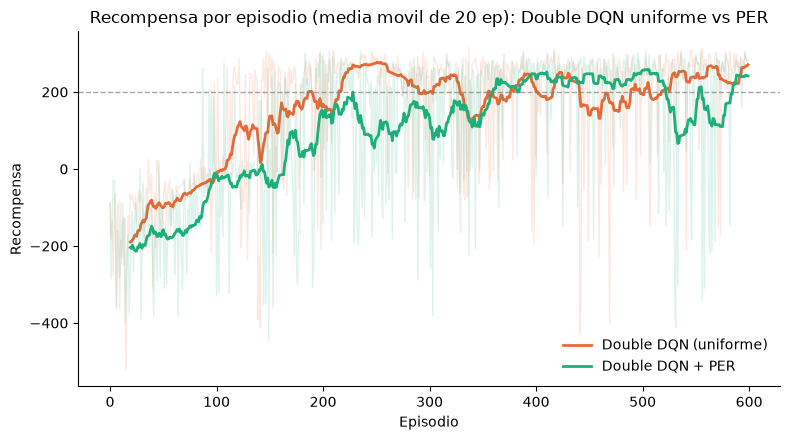

In [16]:
AQUA = "#1baf7a"

fig, ax = plot_reward_curves([
    (double_dqn_logs, ORANGE, "Double DQN (uniforme)"),
    (double_dqn_per_logs, AQUA, "Double DQN + PER"),
])
ax.set_title("Recompensa por episodio (media movil de 20 ep): Double DQN uniforme vs PER")
plt.tight_layout()
plt.show()

Aca nos salio algo que no esperabamos: en esta corrida, Double DQN con PER **no convergio mas rapido**, convergio mas lento y encima termino con menos recompensa que la version uniforme. Viendo los umbrales de recompensa (media movil 20 ep): a 0 de recompensa, uniforme llega en el episodio 110 y PER en el 143; a 200, uniforme llega en el 188 y PER hasta el 361, practicamente el doble de episodios; a 250, uniforme en el 223 y PER en el 411. Al final del entrenamiento uniforme tambien queda arriba: 270.7 contra 241.7 en los ultimos 20 episodios, y la brecha es mas grande todavia si se ve en los ultimos 100 (238.4 contra 176.9).

Donde mas se nota la diferencia es en la fase temprana e intermedia del entrenamiento. Si partimos en tres bloques de 200 episodios: en el bloque 0-200 uniforme ya anda en promedio positivo (17.8) mientras que PER esta bien negativo todavia (-57.7), en el bloque 200-400 uniforme sigue arriba (218.6 vs 155.4), y ya en el bloque 400-600 se acercan bastante mas (215.5 vs 204.8) aunque uniforme sigue ganando un poco. O sea la diferencia es mas visible al principio y a la mitad del entrenamiento, y se reduce (sin desaparecer del todo) hacia el final.

Nuestra hipotesis de por que paso esto: PER muestrea proporcional al error TD, y al inicio del entrenamiento, cuando la red todavia no aprende nada bien, los errores TD mas grandes no necesariamente son "la experiencia mas util para aprender", muchas veces son solo ruido o transiciones de choques con recompensa muy negativa que se repiten una y otra vez en el minibatch. Con $\alpha=0.6$ (una priorizacion bastante fuerte) y $\beta$ arrancando en 0.4 (poca correccion del sesgo de muestreo al inicio, justo cuando mas inestable esta el entrenamiento), el efecto neto puede ser que el agente sobre-entrena en un grupo chico de transiciones ruidosas en vez de ver una muestra mas diversa del buffer, lo cual explicaria por que le cuesta mas despegar. Esto tambien se ve en que el Q promedio de PER sobre los 100 estados fijos termina mas bajo que el de la version uniforme (84.6 contra 114.2), pero el target promedio de PER es un poco mas alto (88.3 contra 79.4), sugiriendo que esta bootstrapeando sobre un conjunto de transiciones con retornos mas variables/con mas outliers.

Igual que en el inciso a, esto es una sola corrida con una sola semilla, entonces no es evidencia definitiva de que "PER es peor que uniforme en LunarLander" en general, pero si nos deja ver que en este entorno especifico, con esta arquitectura chica y esta configuracion de hiperparametros, PER no dio la ventaja de velocidad que uno esperaria de la teoria, y de hecho la fase donde mas se nota es justo la fase donde el entrenamiento es mas inestable (el arranque).

#### d.

Creemos que PER seria **mas beneficioso**, no menos, en el dominio real de deteccion de intrusiones, aunque nuestro propio experimento en LunarLander (inciso c) le haya ido mal. De hecho pensamos que el resultado del inciso c apoya este argumento en vez de contradecirlo.

En LunarLander no hay ningun problema de rareza que resolver: bajo una politica epsilon-greedy, tanto los choques como los aterrizajes exitosos ocurren con frecuencia razonable, entonces el muestreo uniforme ya expone al agente a bastante variedad de "buenas" y "malas" transiciones desde el principio. Ahi lo unico que hace PER es reponderar experiencia que ya era abundante hacia las transiciones con mayor error TD, que al inicio del entrenamiento suelen ser mas ruido que señal util (como vimos en el inciso c, eso parece haberle costado velocidad de convergencia en vez de dar-le). O sea, en LunarLander PER paga el costo (menos diversidad en el minibatch, mas sensibilidad a $\alpha$ y $\beta$) sin resolver un problema real de datos, porque ese problema no existe ahi.

En deteccion de intrusiones si existe ese problema, y lo calculamos en la Task 1.1c: con intrusiones ocurriendo en menos del 0.1% de los pasos, un minibatch de 64 muestreado uniformemente tiene una probabilidad como de 93.8% de no contener ni un solo ejemplo de intrusion ($P(X=0)\approx0.999^{64}$). Osea que sin algo como PER, el agente practicamente nunca recibe una señal de gradiente proveniente de un ataque real, sin importar cuanto tiempo se entrene. Esto es cualitativamente distinto a LunarLander: aca no se trata de "acelerar" el aprendizaje sobre un tipo de evento que igual se ve seguido, sino de si el agente llega a ver ese tipo de evento en la practica.

Entonces el mismo mecanismo que en LunarLander solo reordena experiencia ya abundante, en deteccion de intrusiones seria de los pocos mecanismos disponibles para que las intrusiones (que casi seguro generan errores TD altos las primeras veces que aparecen, precisamente porque el agente no las ha visto) logren aparecer en los minibatches con una frecuencia mucho mayor a su frecuencia real en el trafico. Esa es la diferencia clave: en Lunar Lander PER compite contra una distribucion ya balanceada, en deteccion de intrusiones competiria contra una distribucion extremadamente desbalanceada, que es justo el caso donde el argumento teorico de PER tiene mas fuerza.

Dicho esto, hay que ser cuidadosos con dos cosas que ya habiamos anotado en la Task 1.1c y que el inciso c nos ayudo a ver con mas claridad:

1. PER prioriza por sorpresa (error TD), no por la etiqueta de "es un ataque". Una intrusion que el agente ya aprendio a manejar bien va a tener error TD bajo y va a dejar de priorizarse, aunque siga siendo un evento raro e importante. Entonces PER no reemplaza tener, por ejemplo, una reserva minima garantizada de transiciones criticas conocidas en el minibatch (algo como muestreo estratificado combinado con PER), solo ayuda mientras el error siga siendo alto.
2. El inciso c nos mostro que PER con $\alpha$ alto y $\beta$ bajo al inicio puede desestabilizar el entrenamiento temprano si las transiciones de alto error son mas ruido que señal. En un sistema de seguridad real, esa fase inestable de entrenamiento temprano es mas costosa que en un simulador (las decisiones tienen consecuencias reales), entonces convendria pre-entrenar o calentar la red antes de activar PER a toda su fuerza, o subir $\beta$ mas rapido, para no repetir el mismo problema que vimos aca pero ahora con datos de produccion.

## Referencias 

- **[P]** [Presentación *S12 - Deep RL P1*](../S12%20-%20Deep%20RL%20P1.pdf), *Deep RL Parte 1: DQN y Variantes*, 2026. Experience Replay (4), Target Network (5), Double DQN (8), PER (10) y limitaciones (12).
- **[SB]** Richard S. Sutton y Andrew G. Barto, [*Reinforcement Learning: An Introduction*] **“Second edition, © 2014, 2015**.
